**Why this notebook auto-reloads code**

The next cell enables IPython's `autoreload` so changes you make in the `netsci` module are picked up automatically before each cell runs, without restarting the kernel.

Reference: https://stackoverflow.com/questions/1907993/autoreload-of-modules-in-ipython


In [1]:
# Auto-reload netsci modules if code changes
%load_ext autoreload
%autoreload 2

# Week 6: Dynamics on Networks

**Learning objectives** — After this lab you should be able to:

- Explain the SIR model compartments and parameters (beta, gamma, R_0)
- Simulate the mean-field SIR ODE and interpret the curves
- Run stochastic SIR on a network and compare to the mean-field
- Visualize epidemic snapshots on a graph
- Compare hub seeding vs random seeding for information cascades
- Explain how community structure affects cascade spread
- Compare random, targeted, and acquaintance immunization strategies
- Simulate the voter model and explain how network structure affects consensus time

So far we have studied the **structure** of networks. This week we study what happens
**on** networks — how diseases, information, and influence spread through connections.

The key insight: network structure profoundly affects dynamics.
Hubs accelerate epidemics, and targeted immunization of hubs can stop them.

In [2]:
import networkx as nx
import numpy as np
from scipy.integrate import odeint
from netsci.loaders import load_graph
from netsci.utils import SEED, graph_summary
from netsci.dynamics import (
    network_sir,
    independent_cascade,
    immunize_and_simulate,
    acquaintance_immunize,
    voter_model,
)
from netsci import viz

---
## 1. Datasets

We use two real networks this week:

- **US Airports** (500 nodes, ~2,980 edges) — a hub-and-spoke topology where a few major airports connect to hundreds of others. This structure accelerates epidemic spread because infections can jump between distant regions in a single hop through a hub.
- **Facebook** (334 nodes, ~2,852 edges) — a dense social network with strong community structure. Tight friend-groups act as local "firewalls" that can slow cascades but also trap infections within clusters.

In [3]:
G_air = load_graph("airports")
graph_summary(G_air)
print()
G_fb = load_graph("facebook")
graph_summary(G_fb)

airports: 500 nodes, 2980 edges (undirected)
Graph Summary: Graph
  Type:        undirected
  Nodes:       500
  Edges:       2980
  Density:     0.0239
  Avg degree:  11.92
  Components:  1
  Avg clustering: 0.6175

facebook: 334 nodes, 2852 edges (undirected)
Graph Summary: Graph
  Type:        undirected
  Nodes:       334
  Edges:       2852
  Density:     0.0513
  Avg degree:  17.08
  Components:  1
  Avg clustering: 0.6820


---
## 2. SIR Model Intuition

The **SIR model** divides a population into three compartments:

- **S** (Susceptible) — can catch the disease
- **I** (Infected) — currently sick and can spread the disease
- **R** (Recovered) — immune (or removed)

The flow is: **S → I → R** (no going back!).

Two key parameters:
- **beta** (β): infection rate — probability of transmission per contact
- **gamma** (γ): recovery rate — probability of recovering per time step

The **basic reproduction number** R₀ = β/γ tells us whether the epidemic grows (R₀ > 1) or dies out (R₀ < 1).

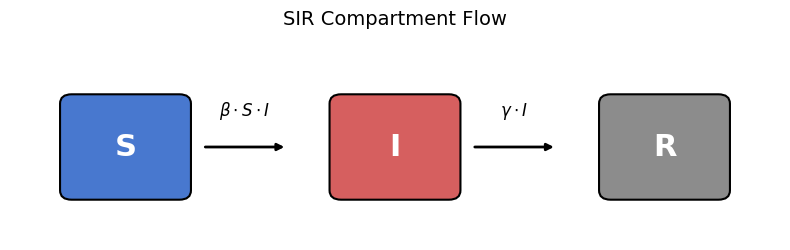

In [4]:
# S → I → R compartment diagram
viz.plot_sir_compartments()

---
## 3. Mean-Field SIR (ODE)

The simplest version assumes everyone mixes uniformly (no network structure). The three ODE equations translate directly into code:

- $dS/dt = -\beta S I$ — the susceptible pool shrinks in proportion to both S and I (more contacts = more infections)
- $dI/dt = +\beta S I - \gamma I$ — the infected pool gains from new infections and loses from recoveries
- $dR/dt = +\gamma I$ — the recovered pool grows as infected individuals heal

Notice: $S + I + R = 1$ at all times (the population is conserved).

R_0 = beta/gamma = 3.0


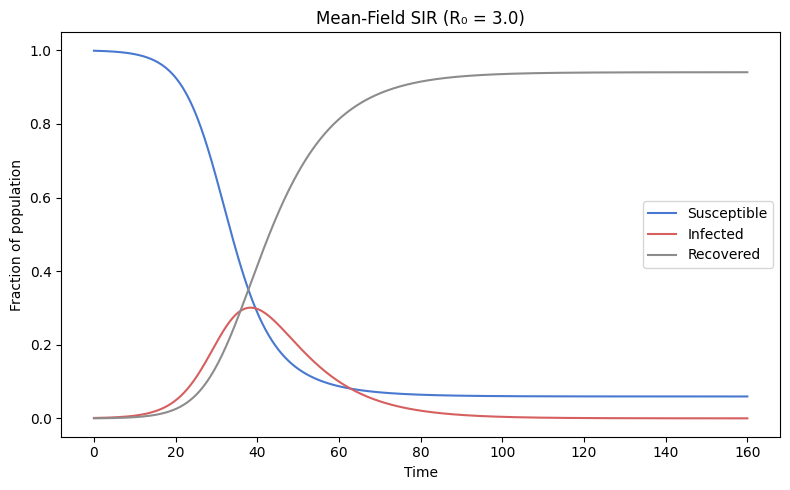

In [5]:
def sir_ode(y, t, beta, gamma):
    """SIR ordinary differential equations."""
    S, I, R = y
    dSdt = -beta * S * I
    dIdt = beta * S * I - gamma * I
    dRdt = gamma * I
    return [dSdt, dIdt, dRdt]


# Parameters
beta_ode, gamma_ode = 0.3, 0.1
R0 = beta_ode / gamma_ode
print(f"R_0 = beta/gamma = {R0:.1f}")

# Initial conditions: 99.9% susceptible, 0.1% infected
y0 = [0.999, 0.001, 0.0]
t = np.linspace(0, 160, 1000)

solution = odeint(sir_ode, y0, t, args=(beta_ode, gamma_ode))
S, I, R = solution.T

viz.plot_sir_ode(t, S, I, R, beta_ode, gamma_ode,
                 title=f"Mean-Field SIR (R₀ = {R0:.1f})")

**Reading the curves**: S decreases monotonically — people only leave the susceptible pool. I peaks then falls as recovery outpaces infection. R increases monotonically and represents the cumulative epidemic size. The peak of I is the moment of maximum strain on healthcare — "flattening the curve" means reducing this peak by lowering R₀. With R₀ = 3.0, roughly 94% of the population eventually gets infected.

**Before you tweak**: What happens when R₀ drops below 1 (try β = 0.05, γ = 0.1)? Predict whether the I curve will still peak, then run the tweak cell to check.

**Try it yourself**: Real networks are heterogeneous — some nodes have many more neighbours than the mean. Heterogeneous mean-field theory says the true threshold on a network is

$$R_0 = \frac{\beta}{\gamma} \cdot \frac{\langle k^2 \rangle}{\langle k \rangle}$$

The ratio $\langle k^2 \rangle / \langle k \rangle$ is the same **Molloy-Reed** quantity we used for percolation in Week 4 — it reappears here as the amplifier hubs apply to $R_0$.

Compute both the naïve $R_0 = (\beta/\gamma)\langle k \rangle$ and the heterogeneous $R_0$ on the airport network for $\beta = 0.05, \gamma = 0.1$. How much do hubs amplify spreading?

In [6]:
# YOUR CODE HERE
degrees_air = np.array([d for _, d in G_air.degree()])
k_mean = degrees_air.mean()
k2_over_k = (degrees_air ** 2).mean() / k_mean

R0_meanfield = (0.05 / 0.1) * k_mean
R0_hetero = (0.05 / 0.1) * k2_over_k

assert k2_over_k >= k_mean - 1e-9, (
    "Hint: ⟨k²⟩/⟨k⟩ ≥ ⟨k⟩ whenever degrees vary (Jensen's inequality)."
)
assert R0_hetero > R0_meanfield, "Hint: hubs amplify R0 above its mean-field value."
print(f"⟨k⟩ = {k_mean:.2f},  ⟨k²⟩/⟨k⟩ = {k2_over_k:.2f}")
print(f"Mean-field     R0 = {R0_meanfield:.2f}")
print(f"Heterogeneous  R0 = {R0_hetero:.2f}   ({R0_hetero/R0_meanfield:.1f}× amplified by hubs)")

⟨k⟩ = 11.92,  ⟨k²⟩/⟨k⟩ = 53.78
Mean-field     R0 = 5.96
Heterogeneous  R0 = 26.89   (4.5× amplified by hubs)


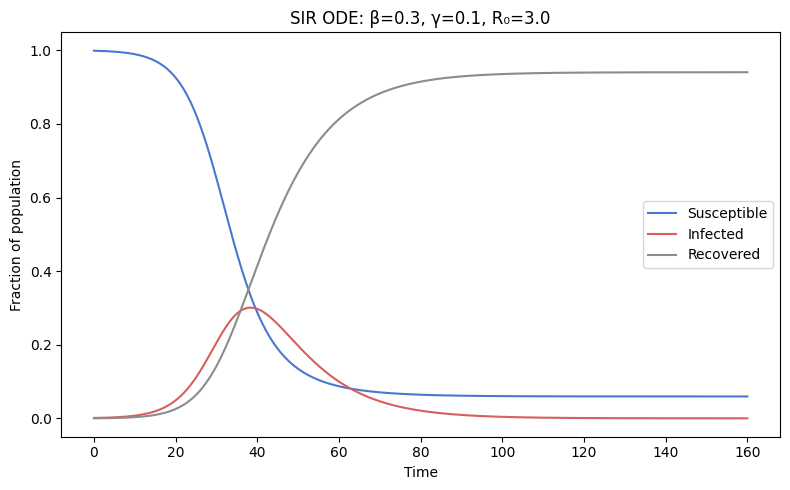

In [7]:
# ---- TWEAK: Change beta and gamma ----
beta_tw = 0.3  # <-- change me (try 0.1, 0.3, 0.5)
gamma_tw = 0.1  # <-- change me (try 0.05, 0.1, 0.2)

R0_tw = beta_tw / gamma_tw
solution_tw = odeint(sir_ode, y0, t, args=(beta_tw, gamma_tw))
S_tw, I_tw, R_tw = solution_tw.T

viz.plot_sir_ode(t, S_tw, I_tw, R_tw, beta_tw, gamma_tw)

---
## 4. Stochastic SIR on a Network

Real people don't mix uniformly — they have specific contacts.
Let's simulate SIR **on the airport network**, where infection can only spread along edges.

The `network_sir()` function below implements stochastic SIR on a graph. The algorithm has three phases each time step:

1. **Infection step** — each infected node independently "rolls the dice" for each susceptible neighbor (probability β). This is where network structure matters: hubs attempt many more infections per step.
2. **Recovery step** — each infected node recovers with probability γ, independently of neighbors.
3. **Update** — newly infected join I, newly recovered move to R. All updates happen simultaneously (no node acts on changes from the same step).

The `rng` parameter ensures reproducible randomness across runs.

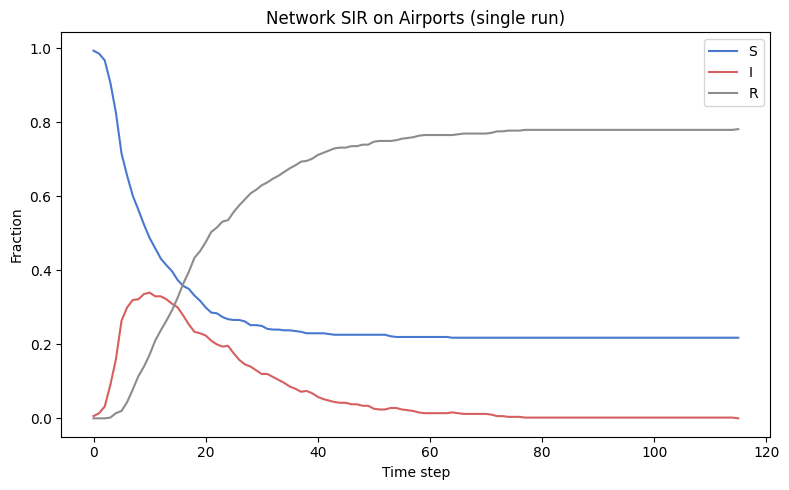

In [8]:
# Single run on airports
result = network_sir(G_air, beta=0.05, gamma=0.1, n_seeds=3)
N = G_air.number_of_nodes()

viz.plot_network_sir_single(result, N, title="Network SIR on Airports (single run)")

**Reading the trajectory**: Compared to the smooth ODE, the network SIR curve is jagged and every run is different. Infection is stochastic — some runs barely take off (the seeds happen to be low-degree nodes) while others explode (a hub gets infected early). The ODE is essentially "the average over infinitely many runs on a fully mixed population" — a useful baseline, but one that hides the variance and the hub-driven heterogeneity that structure produces on real networks.

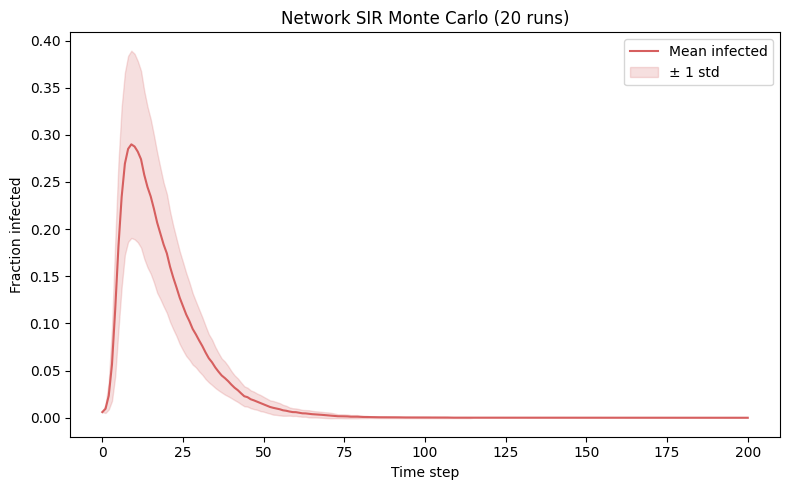

In [9]:
# Monte Carlo: 20 runs, plot mean +/- std
n_runs = 20
max_steps = 200
beta_net, gamma_net = 0.05, 0.1
rng = np.random.default_rng(SEED)

all_I = []
for run in range(n_runs):
    res = network_sir(
        G_air, beta_net, gamma_net, n_seeds=3, max_steps=max_steps, rng=rng
    )
    # Pad to max_steps + 1 if epidemic died early
    I_curve = res["I"] + [0] * (max_steps + 1 - len(res["I"]))
    all_I.append(I_curve[: max_steps + 1])

all_I = np.array(all_I) / N
mean_I = all_I.mean(axis=0)
std_I = all_I.std(axis=0)

viz.plot_network_sir_mc(mean_I, std_I, n_runs)

**Reading the band**: The shaded ±1 std region is widest near the epidemic peak — this is when the outcome is most uncertain. Early on, there are few infected (low variance). Late, most runs have converged (nearly everyone recovered). The peak timing and height are the most variable quantities across runs.

---
## 5. Epidemic Snapshots

Let's visualize the infection spreading through the network at different time points. Watch for:

- **Color wavefront**: green (S) → red (I) → gray (R) spreading outward from the initial seeds.
- **Hub effects**: high-degree airports turn red early and broadcast infection to many neighbours simultaneously.
- **Geographic clusters**: some regions may stay green longer if they are weakly connected to the initial outbreak.

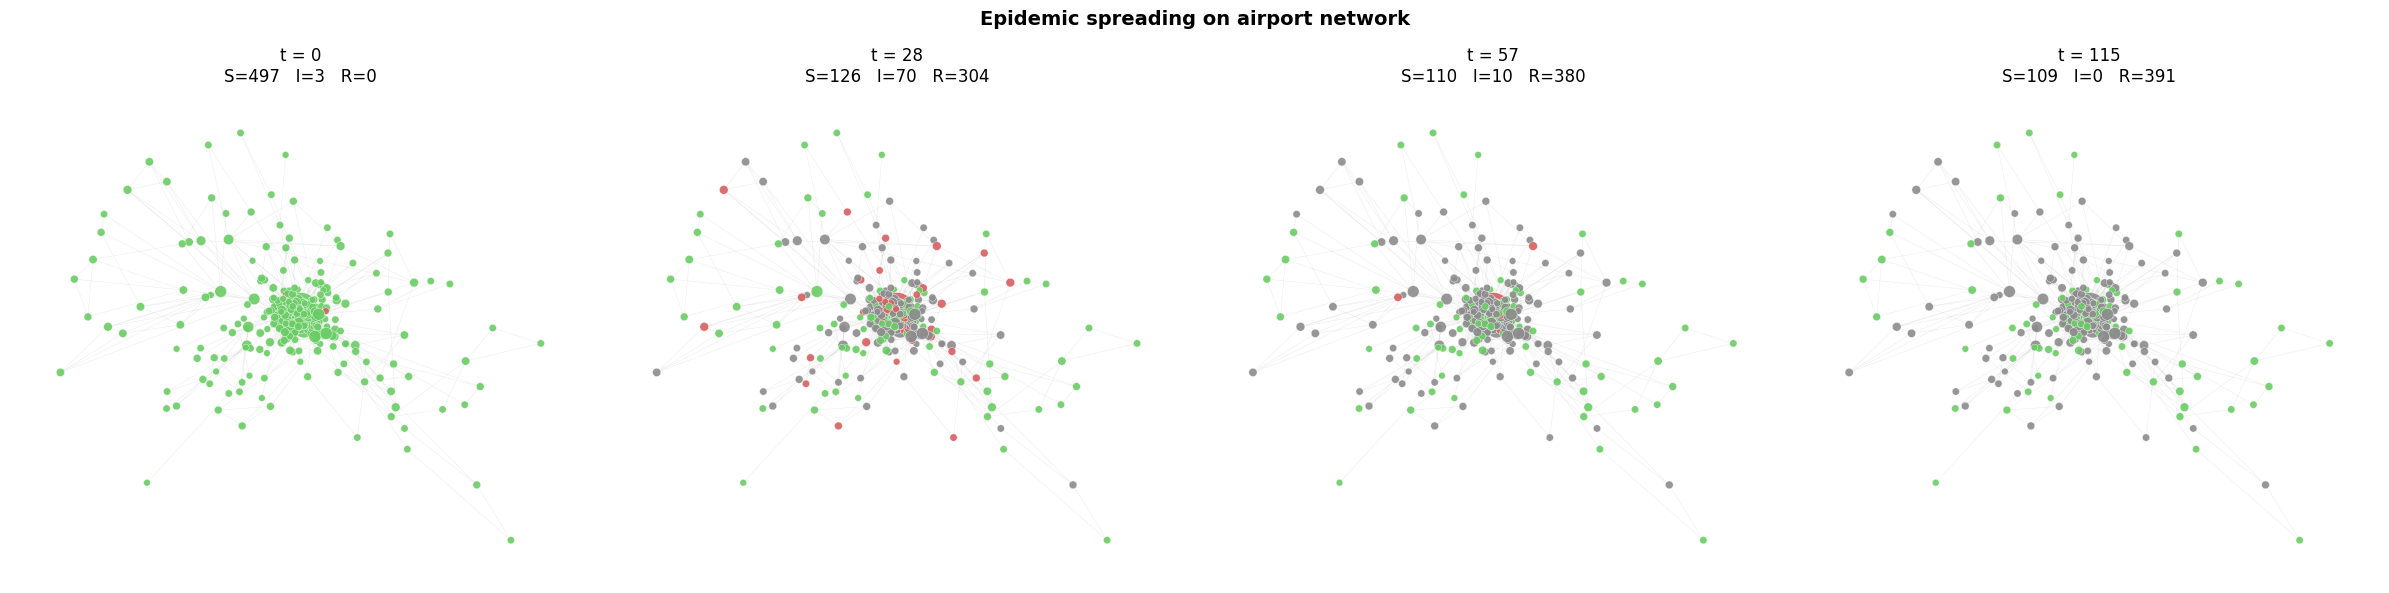

In [10]:
# Run a single epidemic for snapshots
result_snap = network_sir(
    G_air, beta=0.05, gamma=0.1, n_seeds=3, rng=np.random.default_rng(SEED)
)

viz.plot_epidemic_snapshots(
    G_air, result_snap["states"],
    title="Epidemic spreading on airport network",
)

**What you see**: The infection radiates outward from the seed nodes. By t = T/4, hubs are typically already recovered (gray), having served as "superspreader" relay points. The final snapshot shows expanding shells of gray (recovered) surrounding any remaining green (susceptible) pockets — these are the nodes that the epidemic never reached, often in peripheral parts of the network.

---
## 6. Information Cascades

An **independent cascade** is essentially "SIR without recovery" — once a node activates, it stays active forever and gets exactly one chance to activate each neighbour (with probability $p$). This models information spread: once you've heard a rumour, you might tell your friends, but you only try once.

**Predict before you run**: we'll seed the cascade from the top-3 hubs vs 3 random nodes on Facebook, at a low activation probability $p = 0.03$ (deliberately near the takeoff threshold). What matters more here — the **mean reach**, or the **reliability** (variance across trials)? Predict both.

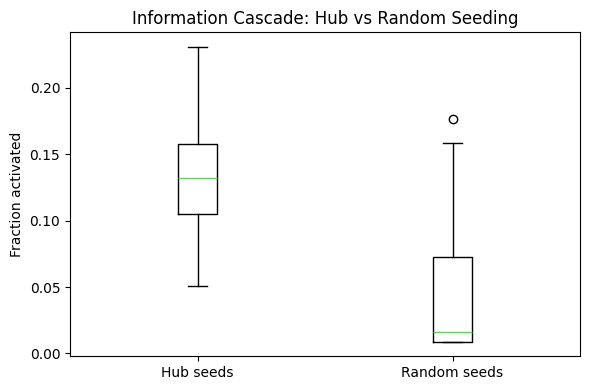

Hub seeds:    13.02% ± 3.99%
Random seeds: 4.65% ± 5.43%
Failed random cascades (<5% reach): 21/30


In [11]:
# Compare hub seeds vs random seeds on Facebook
rng = np.random.default_rng(SEED)
n_trials = 30
n_seeds = 3
p_activate = 0.03

# Hub seeds: top-3 by degree
hubs = sorted(G_fb.nodes(), key=lambda n: G_fb.degree(n), reverse=True)[:n_seeds]
hub_results = []
for _ in range(n_trials):
    activated = independent_cascade(G_fb, hubs, p=p_activate, rng=rng)
    hub_results.append(len(activated) / G_fb.number_of_nodes())

# Random seeds
random_results = []
for _ in range(n_trials):
    rand_seeds = list(rng.choice(list(G_fb.nodes()), size=n_seeds, replace=False))
    activated = independent_cascade(G_fb, rand_seeds, p=p_activate, rng=rng)
    random_results.append(len(activated) / G_fb.number_of_nodes())

viz.plot_cascade_comparison(hub_results, random_results)

print(f"Hub seeds:    {np.mean(hub_results):.2%} ± {np.std(hub_results):.2%}")
print(f"Random seeds: {np.mean(random_results):.2%} ± {np.std(random_results):.2%}")
print(f"Failed random cascades (<5% reach): "
      f"{sum(r < 0.05 for r in random_results)}/{n_trials}")

**Reading the boxplot**: Near the cascade threshold, the difference is not just magnitude but **reliability**. Hub seeds produce a roughly 3× larger mean reach, but the headline result is the tight spread — every trial takes off. Random seeds have a fat downward tail: many trials stall at near-zero reach because the chosen peripheral nodes sit in tight low-degree pockets and the cascade dies before it can escape. Hubs start with many first-hop neighbours, those neighbours are themselves well-connected, and hubs tend to bridge multiple communities (Week 5), so the cascade gets simultaneous footholds. This is the network-science view of "superspreader events": a single well-connected individual doesn't just spread faster — they make takeoff *reliable* at parameters where random seeding usually fizzles.

---
## 7. Immunization Strategies

If we can vaccinate some fraction of the population, **which nodes should we choose?** In Week 4 we saw that targeted hub removal shatters scale-free networks. Now we use that insight for epidemic control. The two obvious strategies sit at opposite ends of a **cost-information tradeoff**:

- **Random immunization** needs no knowledge of the network — just vaccinate people at random. Simple and fair, but inefficient when hubs dominate spreading.
- **Targeted immunization** removes the highest-degree nodes first. Very effective, but requires knowing the full degree sequence, which is rarely available in practice.

**Predict before you run**: at 10% coverage on the airport network, how much lower will the peak infected fraction be under targeted vs random immunization? Same? 2× lower? 10× lower? Anchor your guess in last week's ⟨k²⟩/⟨k⟩ argument, not intuition alone.

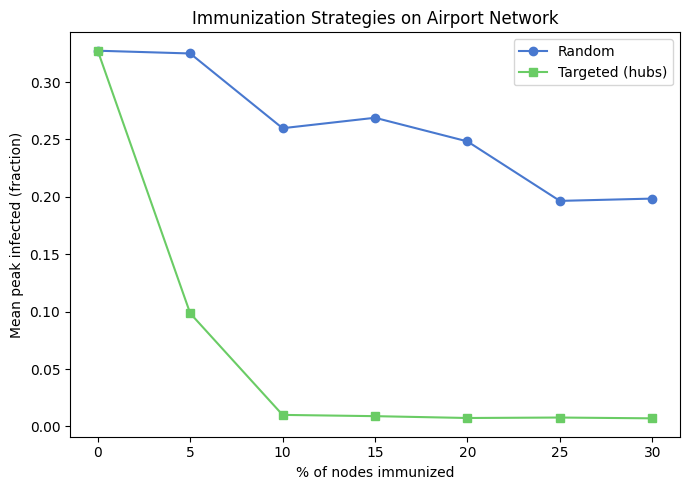

In [12]:
# Sweep immunization fraction
fractions = np.arange(0, 0.31, 0.05)
peaks_random = [immunize_and_simulate(G_air, f, "random") for f in fractions]
peaks_targeted = [immunize_and_simulate(G_air, f, "targeted") for f in fractions]

viz.plot_immunization_sweep(
    fractions,
    {"Random": (peaks_random, "o"), "Targeted (hubs)": (peaks_targeted, "s")},
    title="Immunization Strategies on Airport Network",
)

**Key observation**: removing just 10-15% of the highest-degree nodes dramatically reduces the epidemic peak. Random removal of the same fraction barely helps. This is because hubs are the "superspreaders" that connect different parts of the network.

### Acquaintance Immunization

We saw that targeted immunization requires knowing the full degree sequence — rarely available in practice. **Acquaintance immunization** offers a clever middle ground:

1. Pick a random person
2. Ask them to name a friend
3. Vaccinate the friend (not the original person)

By the **friendship paradox**, the named friend has higher-than-average degree. This biased sampling preferentially hits hubs *without needing global network information*.

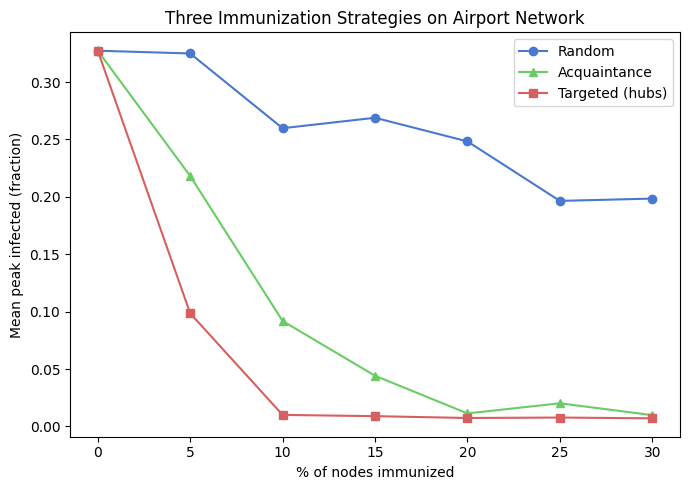

In [13]:
# Compare all three strategies
fractions_imm = np.arange(0, 0.31, 0.05)
peaks_random_3 = []
peaks_targeted_3 = []
peaks_acquaintance = []

for f in fractions_imm:
    rng_acq = np.random.default_rng(SEED)
    if f == 0.0:
        res = immunize_and_simulate(G_air, 0, "none")
        peaks_random_3.append(res)
        peaks_targeted_3.append(res)
        peaks_acquaintance.append(res)
    else:
        peaks_random_3.append(immunize_and_simulate(G_air, f, "random"))
        peaks_targeted_3.append(immunize_and_simulate(G_air, f, "targeted"))
        # Acquaintance
        G_acq = acquaintance_immunize(G_air, f, rng_acq)
        if G_acq.number_of_nodes() > 4:
            rng_sim = np.random.default_rng(SEED)
            acq_peaks = []
            for _ in range(20):
                res_acq = network_sir(
                    G_acq, 0.05, 0.1, n_seeds=3, max_steps=100, rng=rng_sim
                )
                acq_peaks.append(max(res_acq["I"]) / G_air.number_of_nodes())
            peaks_acquaintance.append(np.mean(acq_peaks))
        else:
            peaks_acquaintance.append(0.0)

viz.plot_immunization_sweep(
    fractions_imm,
    {
        "Random": (peaks_random_3, "o"),
        "Acquaintance": (peaks_acquaintance, "^"),
        "Targeted (hubs)": (peaks_targeted_3, "s"),
    },
    title="Three Immunization Strategies on Airport Network",
)

**Acquaintance immunization in action**: The acquaintance strategy performs significantly better than random immunization and approaches targeted immunization — all without needing global knowledge of the network. This is the friendship paradox at work: by asking random people to name friends, we oversample high-degree nodes (hubs), achieving near-targeted effectiveness with only local information.

This has real public health implications: during an outbreak, you don't need a census of everyone's contacts. Just ask random people "who do you interact with most?" and prioritize vaccinating those named individuals.

---
## 8. Opinion Dynamics: The Voter Model

Epidemics are one type of dynamics on networks. Another fundamental process is **opinion formation** — how do competing opinions spread and when does a population reach consensus?

The **voter model** is the simplest model of opinion dynamics:
1. Each node holds one of two opinions (say, 0 or 1)
2. At each time step, pick a random node
3. That node copies the opinion of a randomly chosen neighbor
4. Repeat until consensus (all nodes agree) or a time limit

Unlike SIR (which has a one-way flow S→I→R), the voter model allows opinions to flip back and forth. The key question: **how does network structure affect the time to reach consensus?**

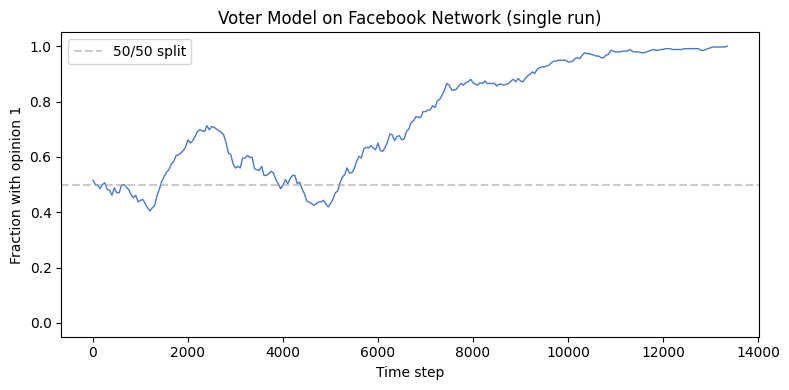

In [14]:
# Run voter model on Facebook network
rng_voter = np.random.default_rng(SEED)
result_voter = voter_model(G_fb, max_steps=50000, rng=rng_voter)

viz.plot_voter_trajectory(
    result_voter["fraction_1"],
    title="Voter Model on Facebook Network (single run)",
)

**Reading the voter model trajectory**: The fraction of opinion 1 follows a random walk that eventually absorbs at 0 or 1 (consensus). The trajectory is noisy because the model is inherently stochastic — at each step, a single node flips. On a well-connected network like Facebook, the walk can hover near 50/50 for a long time before one opinion wins by chance. The community structure can create temporary "plateaus" where each community locks into a different opinion, slowing consensus.

**Predict before you run**: we'll compare the same voter dynamics on three networks — a **complete graph** (every node is everyone's neighbour), a **ring lattice** (only nearest neighbours), and **Facebook** (hubs plus community structure). Rank them from fastest to slowest consensus. Where does Facebook sit — closer to the complete graph, or closer to the ring? Why?

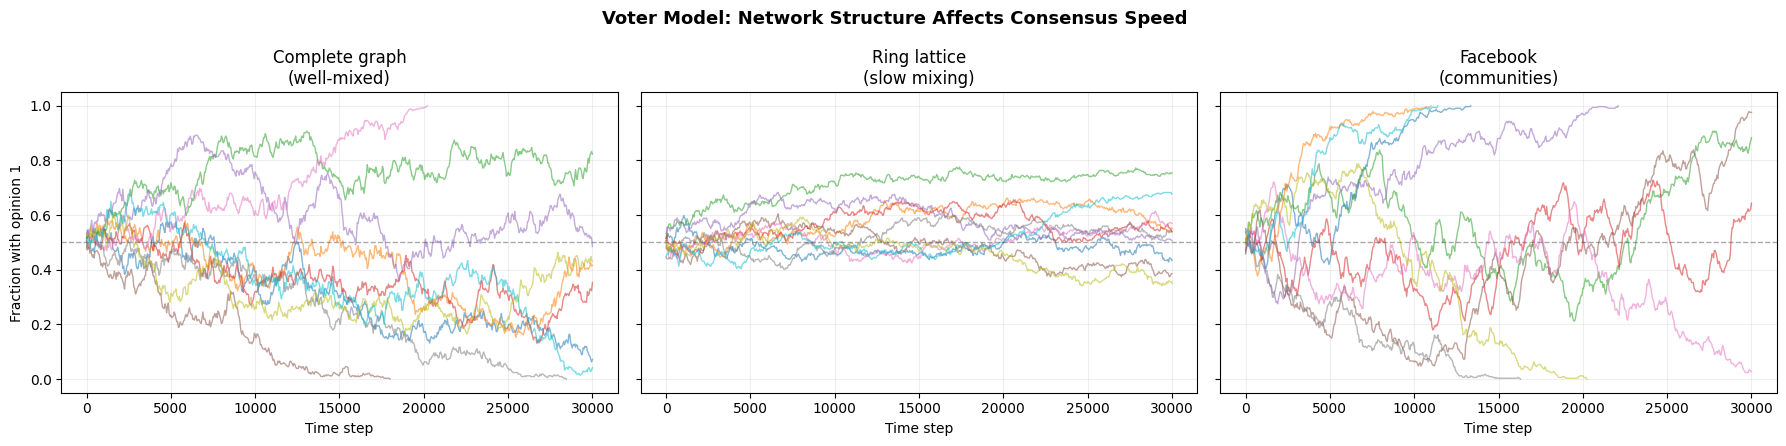

In [15]:
# Compare voter model on different network structures
# Complete graph (well-mixed) vs ring lattice (slow mixing) vs Facebook (communities)
G_complete = nx.complete_graph(G_fb.number_of_nodes())
G_ring = nx.watts_strogatz_graph(G_fb.number_of_nodes(), 4, 0, seed=SEED)

n_runs = 10
max_steps = 30000

networks = [
    ("Complete graph\n(well-mixed)", G_complete),
    ("Ring lattice\n(slow mixing)", G_ring),
    ("Facebook\n(communities)", G_fb),
]

runs_by_network = []
for name, G in networks:
    rng_v = np.random.default_rng(SEED)
    runs = []
    for _ in range(n_runs):
        res = voter_model(G, max_steps=max_steps, rng=rng_v)
        runs.append(res["fraction_1"])
    runs_by_network.append((name, runs))

viz.plot_voter_comparison(runs_by_network)

**Structure shapes consensus**: On a complete graph (left), every node is a neighbor of every other — opinions mix rapidly and consensus arrives quickly. On a ring lattice (center), information can only propagate locally, so it takes much longer for one opinion to dominate. Facebook (right) sits between these extremes: communities can reach internal consensus quickly, but the sparse between-community bridges slow global agreement. This echoes a real-world phenomenon — echo chambers form when communities internally agree but resist external influence.

**Epidemics vs opinions**: Notice a key difference from SIR. In epidemics, the process has a direction (S→I→R) and eventually dies out. In the voter model, opinions can flip indefinitely — the only absorbing states are full consensus. This makes the voter model a better analogy for political polarization, technology adoption, and cultural norms, where "recovery" (changing your mind) is always possible.

---
## Summary

| Concept | Key insight |
|---------|-------------|
| **SIR model** | S → I → R with rates β (infection) and γ (recovery) |
| **R₀ = β/γ** | Epidemic threshold — grows if R₀ > 1 |
| **Network SIR** | Structure matters — hubs accelerate spread |
| **Targeted immunization** | Removing hubs is far more effective than random |
| **Acquaintance immunization** | Friendship paradox enables near-targeted results with only local info |
| **Information cascades** | Hub seeds reach more people; communities slow cross-group spread |
| **Voter model** | Opinion dynamics where nodes copy neighbors; network structure affects consensus time |
| **Echo chambers** | Communities reach internal consensus quickly but resist cross-boundary influence |

See Week 4 for the Molloy-Reed criterion and robustness paradox.

This concludes the 6-week Network Science Lab Course. You now have the tools to:
- Build and analyze networks
- Measure their properties
- Detect communities
- Simulate dynamics (epidemics, opinions, cascades)
- Make informed decisions about network interventions